# 01 - Quickstart & Continuous Particle Size Distributions (PSD)
### poropack: 3D Porous Media & Digital Rock Physics Generator

This notebook introduces the core architecture of `poropack`:
1. **Decoupled Representations**: High-precision Lagrangian `GrainPack` and Eulerian `VoxelGrid`.
2. **Geological Particle Size Distributions (PSD)**: Log-Normal, Weibull, and Sieve curves with analytical Hatch-Choate volume-to-number transformations.
3. **Accelerated RSA Generation**: $O(1)$ spatial hash grid collision detection (`PeriodicSpatialGrid`) with periodic boundary conditions.
4. **Voxel Rasterization & Orthogonal Slice Visualization**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import poropack as pp

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print(f'poropack version: {pp.__version__}')


poropack version: 2.0.0


## 1. Continuous Geological Particle Size Distributions (PSD)

In reservoir sedimentology and Digital Rock Physics (DRP), natural sandstones and unconsolidated sediments exhibit continuous particle size distributions parameterized by:
- **Median Diameter ($d_{50}$)**: Representative particle diameter.
- **Folk-Ward Sorting Coefficient ($\sigma_\phi$)**: In Krumbein phi scale ($\phi = -\log_2(d)$):
  - Well sorted: $\sigma_\phi < 0.50$
  - Moderately sorted: $0.71 \le \sigma_\phi \le 1.00$
  - Poorly sorted: $\sigma_\phi > 1.00$

### Analytical Hatch-Choate Conversion
Standard laboratory sieve analysis measures **volume- or mass-weighted** fractions. When populating particle coordinates stochastically, particles must be sampled from the **number-weighted** frequency density.

`poropack` performs this transformation analytically via the **Hatch-Choate equation**:
$$\ln(d_{50,N}) = \ln(d_{50,V}) - 3 (\ln \sigma_g)^2, \quad 	ext{where } \ln \sigma_g = \sigma_\phi \ln 2$$


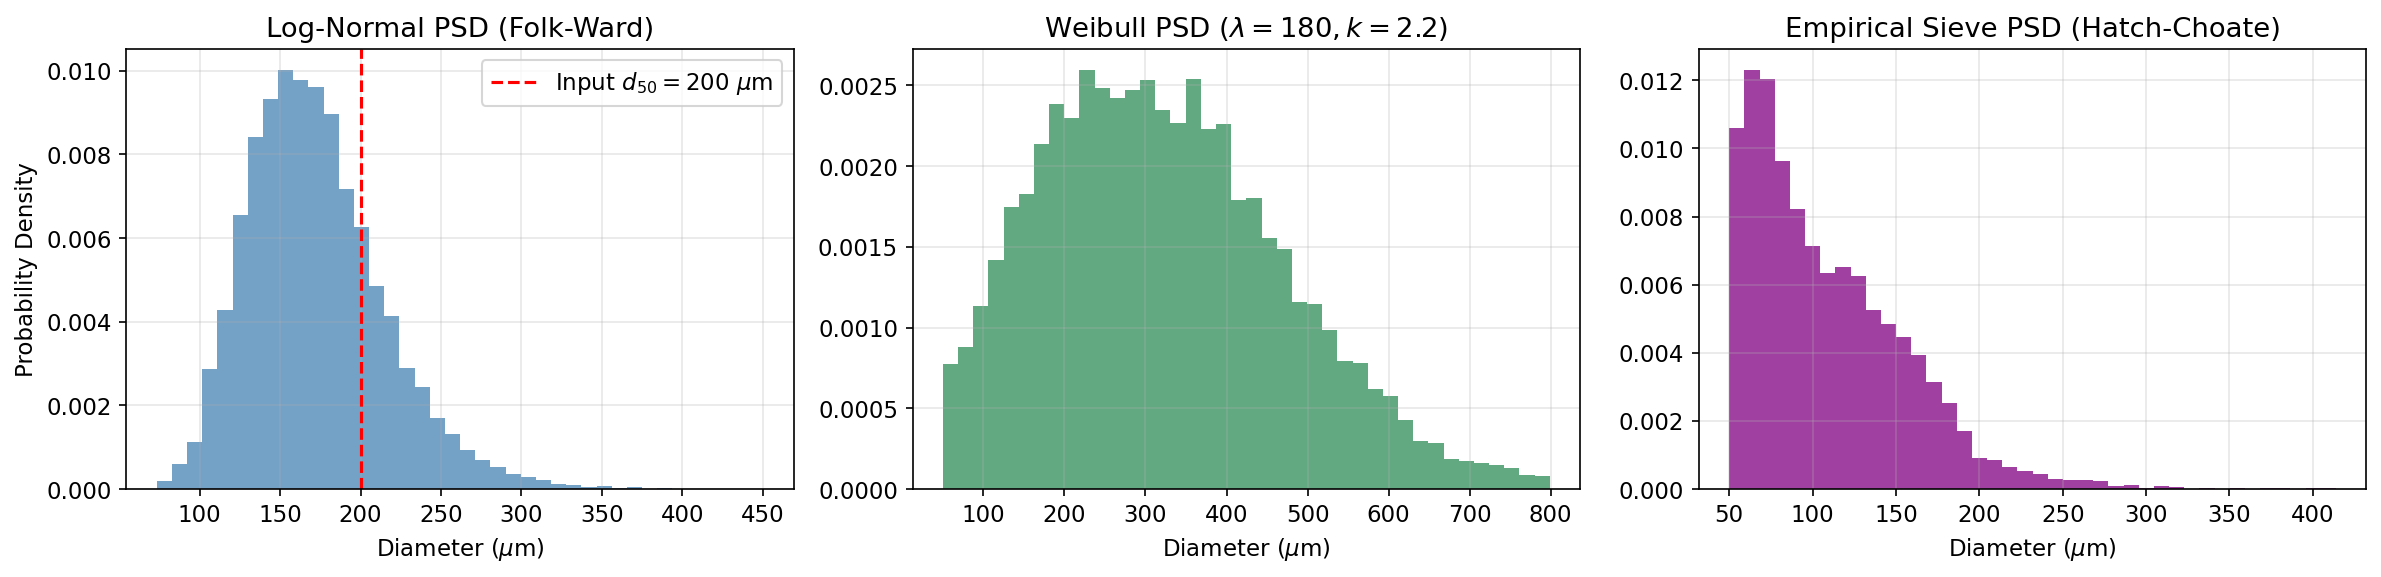

In [2]:
# 1. Define geological LogNormalPSD (well-sorted medium sand: d50 = 200 um, sigma_phi = 0.35)
psd_ln = pp.LogNormalPSD(d50=200.0, sigma_phi=0.35, bounds=(30.0, 450.0))

# 2. Define WeibullPSD for positively skewed sediment distributions
psd_wb = pp.WeibullPSD(scale=180.0, shape=2.2, bounds=(25.0, 400.0))

# 3. Define EmpiricalSievePSD from lab sieve mesh data with volume-to-number transformation
sieve_mesh = [50.0, 100.0, 150.0, 200.0, 300.0, 425.0]
pct_passing = [2.0, 12.0, 38.0, 72.0, 94.0, 100.0]
psd_sieve = pp.EmpiricalSievePSD(diameters=sieve_mesh, percent_passing=pct_passing, volume_weighted=True)

# Sample 10,000 grain radii from each distribution
rng = np.random.default_rng(42)
r_ln = psd_ln.sample(10000, rng=rng)
r_wb = psd_wb.sample(10000, rng=rng)
r_sieve = psd_sieve.sample(10000, rng=rng)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(r_ln * 2.0, bins=40, density=True, color='steelblue', alpha=0.75)
axes[0].axvline(200.0, color='red', linestyle='--', label=r'Input $d_{50} = 200\ \mu\mathrm{m}$')
axes[0].set_title('Log-Normal PSD (Folk-Ward)')
axes[0].set_xlabel(r'Diameter ($\mu\mathrm{m}$)')
axes[0].set_ylabel('Probability Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(r_wb * 2.0, bins=40, density=True, color='seagreen', alpha=0.75)
axes[1].set_title(r'Weibull PSD ($\lambda=180, k=2.2$)')
axes[1].set_xlabel(r'Diameter ($\mu\mathrm{m}$)')
axes[1].grid(True, alpha=0.3)

axes[2].hist(r_sieve * 2.0, bins=40, density=True, color='purple', alpha=0.75)
axes[2].set_title('Empirical Sieve PSD (Hatch-Choate)')
axes[2].set_xlabel(r'Diameter ($\mu\mathrm{m}$)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 2. Accelerated Random Sequential Adsorption (RSA)

Traditional RSA algorithm checks for overlapping particles via brute-force pairwise loops ($O(N^2)$), causing execution times to blow up exponentially for large systems.

`poropack.RSAGenerator` uses an $O(1)$ spatial hash grid (`PeriodicSpatialGrid`) with cell size $d_{	ext{cell}} \ge 2r_{\max}$. It evaluates only the immediate 27 neighboring cells under minimum-image periodic boundary conditions, placing thousands of grains in milliseconds.


In [3]:
# Generate a 3D grain pack of size 800 x 800 x 800 um with 2 um throat clearance
rsa = pp.RSAGenerator(
    box_size=(800.0, 800.0, 800.0),
    psd=psd_ln,
    min_throat=2.0,
    periodic=(True, True, True),
    random_state=42,
)

# Target porosity: 0.65
pack = rsa.generate(target_porosity=0.65)
print('Lagrangian GrainPack Generation Summary:')
print(f'  Grains Placed:       {len(pack)}')
print(f'  Analytical Porosity: {pack.analytical_porosity():.4f}')
print(f'  Total Solid Volume:  {pack.solid_volume:.2e} um^3')


Lagrangian GrainPack Generation Summary:
  Grains Placed:       152
  Analytical Porosity: 0.6498
  Total Solid Volume:  1.79e+08 um^3


## 3. Eulerian VoxelGrid Rasterization & Orthogonal Slices

Convert the continuous Lagrangian `GrainPack` into a discrete binary `VoxelGrid` at arbitrary isotropic voxel resolution $h$ (e.g. $8\ \mu\mathrm{m}$).
Toroidal boundary wrap-around ensures grains crossing domain boundaries re-enter opposite faces without boundary skin effects.


VoxelGrid Dimensions: (100, 100, 100)
Voxel Domain Porosity: 0.6499


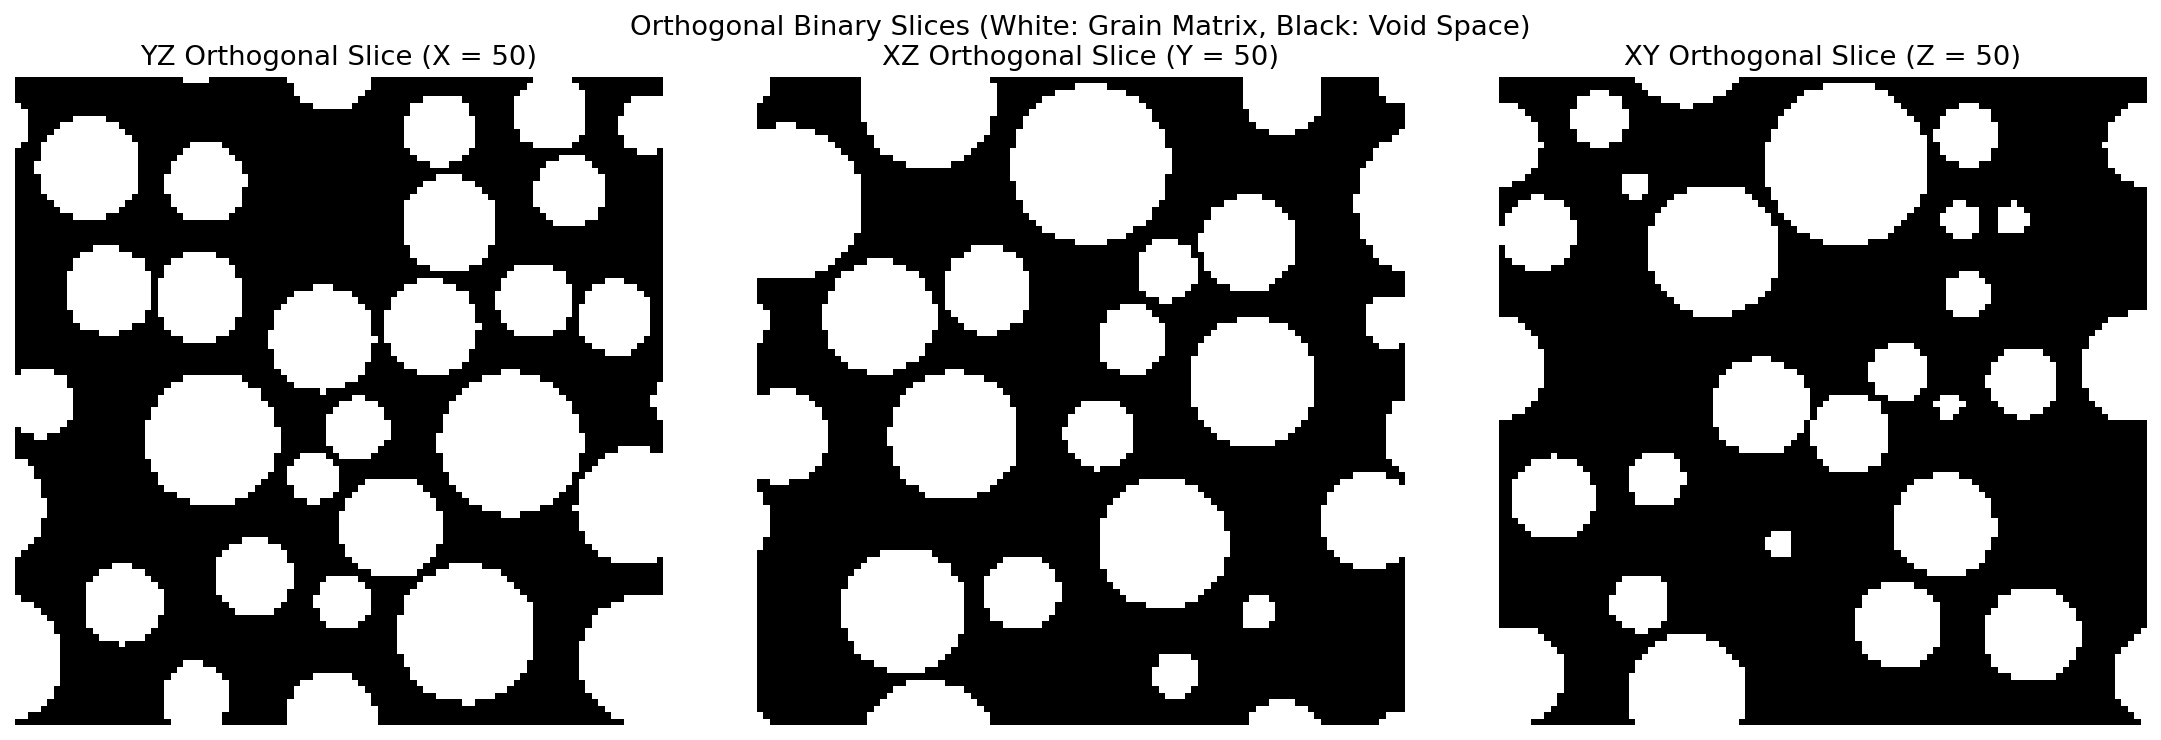

In [4]:
# Rasterize at 8 um voxel resolution
voxel_grid = pack.rasterize(voxel_size=8.0)
print(f'VoxelGrid Dimensions: {voxel_grid.shape}')
print(f'Voxel Domain Porosity: {voxel_grid.porosity():.4f}')

# Plot orthogonal slice views
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(voxel_grid.matrix[50, :, :], cmap='bone')
axes[0].set_title('YZ Orthogonal Slice (X = 50)')
axes[1].imshow(voxel_grid.matrix[:, 50, :], cmap='bone')
axes[1].set_title('XZ Orthogonal Slice (Y = 50)')
axes[2].imshow(voxel_grid.matrix[:, :, 50], cmap='bone')
axes[2].set_title('XY Orthogonal Slice (Z = 50)')
for ax in axes: ax.axis('off')
plt.suptitle('Orthogonal Binary Slices (White: Grain Matrix, Black: Void Space)')
plt.tight_layout()
plt.show()
